In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Set style for notebook visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [7]:
# Load dataset
df = pd.read_csv('Traffic_Violations_Cleaned.csv')
print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (1166560, 45)


# Q1 — What are the most common violations?

Top 10 Most Common Traffic Violations:
Description
driver failure to obey properly placed traffic control device instructions                              125255
driver using hands to use handheld telephone whilemotor vehicle is in motion                             41230
exceeding the posted speed limit of 40 mph                                                               38078
driving vehicle on highway with suspended registration                                                   37846
exceeding the posted speed limit of 35 mph                                                               34985
failure to display registration card upon demand by police officer                                       32879
displaying expired registration plate issued by any state                                                32640
driver failure to stop at stop sign line                                                                 31233
exceeding the posted speed limit of 30 mph                   

C:\Users\Krishnika Arun\AppData\Local\Temp\ipykernel_2596\4115292765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_violations.index, x=top_violations.values, palette="viridis")


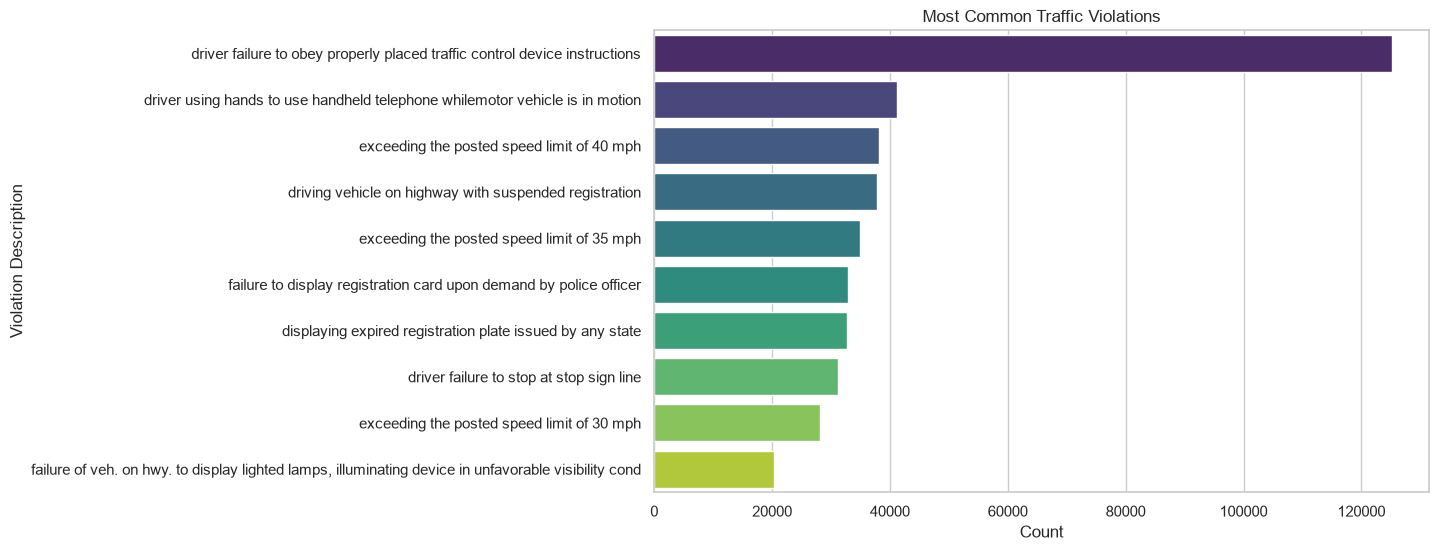

In [8]:
if 'Description' in df.columns:
    # Calculate top 10 violations
    top_violations = df['Description'].value_counts().head(10)
    
    print("Top 10 Most Common Traffic Violations:")
    print(top_violations)
    
    # Plot results
    sns.barplot(y=top_violations.index, x=top_violations.values, palette="viridis")
    plt.title("Most Common Traffic Violations")
    plt.xlabel("Count")
    plt.ylabel("Violation Description")
    plt.show()
else:
    print("Column 'Description' not found.")

# Q2 — Which areas or coordinates have the highest traffic incidents?

Top 10 High-Incident Locations (Text-Based):
Location
10901 WESTLAKE DRIVE                    1467
RT 28 @ BLACKBERRY DR                   1402
W/B IS 370 @ IS 270                     1261
WOODFIELD RD @ EMORY GROVE RD           1236
RIDGE RD @ OBSERVATION DR               1216
CONNECTICUT AVE @ DEAN RD               1171
MONTGOMERY VILLAGE AVE @ RUSSELL AVE    1123
RIVER RD @ ROYAL DOMINION DR            1059
COLESVILLE RD @ GEORGIA AVE             1046
WAYNE AVE @ DALE DR                      993
Name: count, dtype: int64


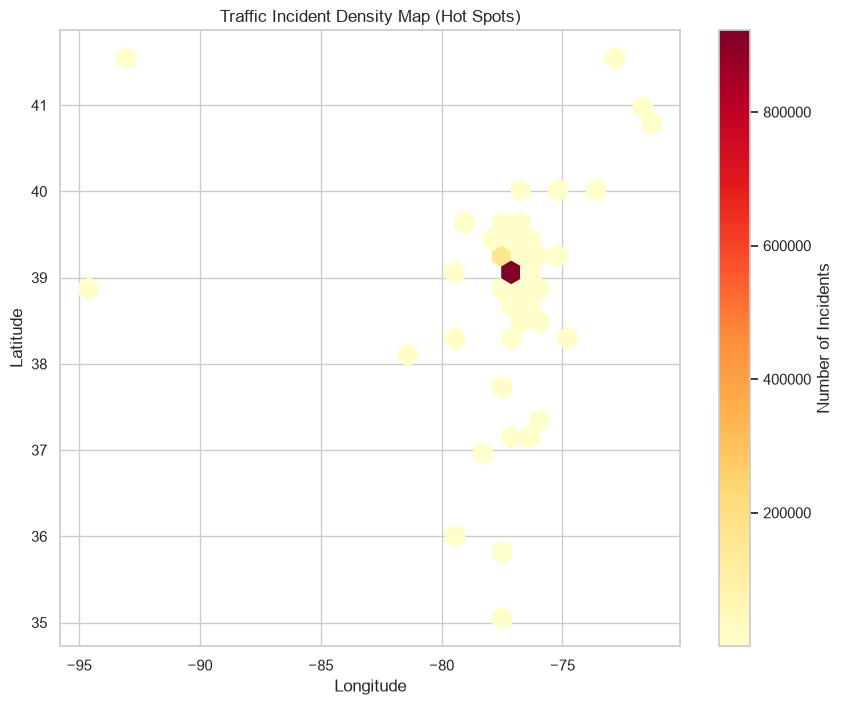

In [9]:
if 'Location' in df.columns:
    top_locations = df['Location'].value_counts().head(10)
    print("Top 10 High-Incident Locations (Text-Based):")
    print(top_locations)

# Coordinate Density Analysis
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    # Drop rows without valid coordinates for plotting
    geo_df = df.dropna(subset=['Latitude', 'Longitude'])
    
    if not geo_df.empty:
        plt.figure(figsize=(10, 8))
        # Using a hexbin or scatter to spot incident hot spots visually
        plt.hexbin(geo_df['Longitude'], geo_df['Latitude'], gridsize=30, cmap='YlOrRd', mincnt=1)
        plt.colorbar(label='Number of Incidents')
        plt.title("Traffic Incident Density Map (Hot Spots)")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()

# Q3 — Do certain demographics correlate with specific violation types?

Demographic Correlation Matrix (% of Violation Type by Race Group):


Violation Type,Citation,ESERO,SERO,Warning
Race,,,,
ASIAN,35.41,4.31,0.03,60.26
BLACK,36.77,4.04,0.04,59.16
HISPANIC,41.06,4.93,0.04,53.97
NATIVE AMERICAN,35.34,6.36,0.00,58.30
OTHER,33.97,3.22,0.02,62.80
WHITE,37.56,3.27,0.03,59.14


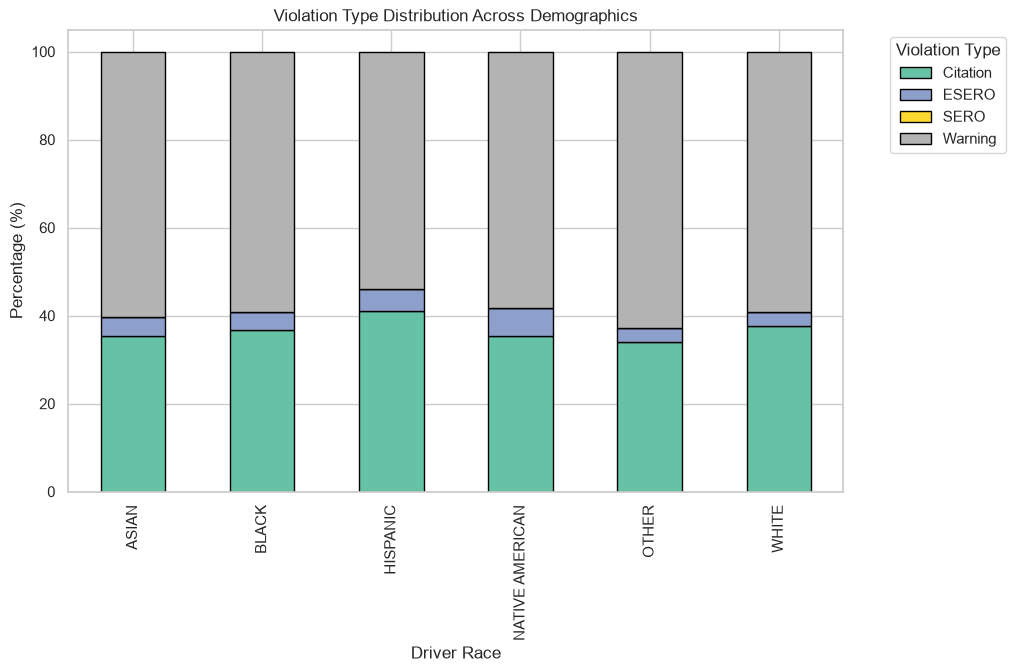

In [10]:
if 'Race' in df.columns and 'Violation Type' in df.columns:
    # Create normalized cross-tabulation table (percentages per demographic group)
    demographic_cross = pd.crosstab(df['Race'], df['Violation Type'], normalize='index') * 100
    
    print("Demographic Correlation Matrix (% of Violation Type by Race Group):")
    display(demographic_cross.round(2))
    
    # Stacked bar plot for visualization
    demographic_cross.plot(kind='bar', stacked=True, cmap='Set2', edgecolor='black')
    plt.title("Violation Type Distribution Across Demographics")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Driver Race")
    plt.legend(title="Violation Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
else:
    print("Demographic or Violation columns missing.")

# Q4 — How does violation frequency vary by time of day, weekday, or month?

In [15]:
# Q4a: Hourly Distribution
if 'Hour' in df.columns:
    plt.figure(figsize=(12, 5))
    
    # Calculate order/counts for clean plotting
    sns.countplot(data=df, x='Hour', palette="Blues_d")
    
    plt.title("Traffic Violations broken down by Hour of Day", fontsize=14, pad=15)
    plt.xlabel("Hour of Day (24-Hour Clock)", fontsize=12)
    plt.ylabel("Number of Violations", fontsize=12)
    plt.xticks(range(0, 24))  # Ensure all hours 0-23 display clearly
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Hour' not found. Ensure Cell 2 ran successfully.")

Column 'Hour' not found. Ensure Cell 2 ran successfully.


# Q5 — What types of vehicles are most often involved in violations?

In [18]:
# Re-running a safer extraction for Temporal Features
if 'Date Of Stop' in df.columns:
    # Ensure it's in datetime format
    df['Date Of Stop'] = pd.to_datetime(df['Date Of Stop'], errors='coerce')
    
    # Extract Weekday and Month directly from the Date column (ignores Time)
    df['Weekday'] = df['Date Of Stop'].dt.day_name()
    df['Month'] = df['Date Of Stop'].dt.month_name()

# Handle Hour separately from the Time column
if 'Time Of Stop' in df.columns:
    # Standardize dots to colons
    df['Time Of Stop'] = df['Time Of Stop'].astype(str).str.replace('.', ':', regex=False)
    # Convert to timedelta
    time_delta = pd.to_timedelta(df['Time Of Stop'], errors='coerce')
    # Extract the hour component safely
    df['Hour'] = time_delta.dt.components['hours']

print("Columns successfully rebuilt:")
print(f"- Weekday missing values: {df['Weekday'].isna().sum()}")
print(f"- Month missing values: {df['Month'].isna().sum()}")
print(f"- Hour missing values: {df['Hour'].isna().sum()}")

Columns successfully rebuilt:
- Weekday missing values: 0
- Month missing values: 0
- Hour missing values: 0


### Violations by Hour of Day

Top Vehicle Classifications Involved:
VehicleType
02 - Automobile              1035306
05 - Light Duty Truck          65133
28 - Other                     22819
03 - Station Wagon             17955
01 - Motorcycle                 8682
06 - Heavy Duty Truck           7561
08 - Recreational Vehicle       4179
07 - Truck/Road Tractor          973
Name: count, dtype: int64


C:\Users\Krishnika Arun\AppData\Local\Temp\ipykernel_2596\4265805875.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vehicles.values, y=top_vehicles.index, palette="rocket")


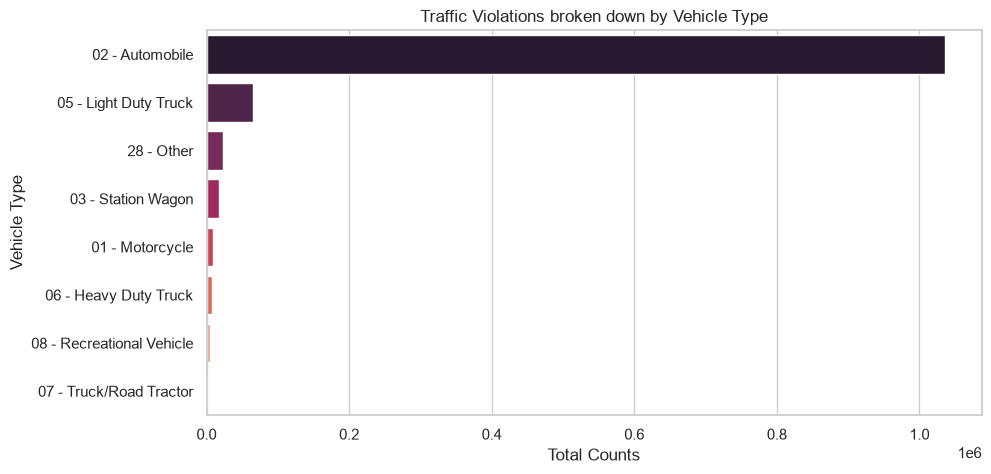

In [19]:
if 'VehicleType' in df.columns:
    top_vehicles = df['VehicleType'].value_counts().head(8)
    
    print("Top Vehicle Classifications Involved:")
    print(top_vehicles)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_vehicles.values, y=top_vehicles.index, palette="rocket")
    plt.title("Traffic Violations broken down by Vehicle Type")
    plt.xlabel("Total Counts")
    plt.ylabel("Vehicle Type")
    plt.show()

## Violations by Day of the Week

C:\Users\Krishnika Arun\AppData\Local\Temp\ipykernel_2596\399707236.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Weekday', order=day_order, palette="GnBu_d")


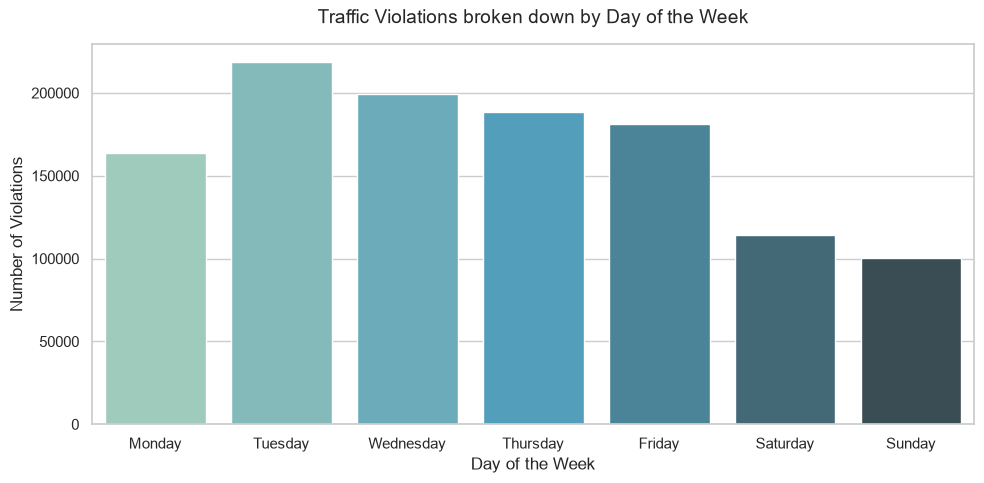

In [20]:
# Q4b: Day of Week Distribution
if 'Weekday' in df.columns:
    plt.figure(figsize=(10, 5))
    
    # Enforce chronological day order instead of arbitrary sorting
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    sns.countplot(data=df, x='Weekday', order=day_order, palette="GnBu_d")
    
    plt.title("Traffic Violations broken down by Day of the Week", fontsize=14, pad=15)
    plt.xlabel("Day of the Week", fontsize=12)
    plt.ylabel("Number of Violations", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Weekday' not found.")

## Violations by Month

C:\Users\Krishnika Arun\AppData\Local\Temp\ipykernel_2596\134799826.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Month', order=existing_months, palette="Purples_d")


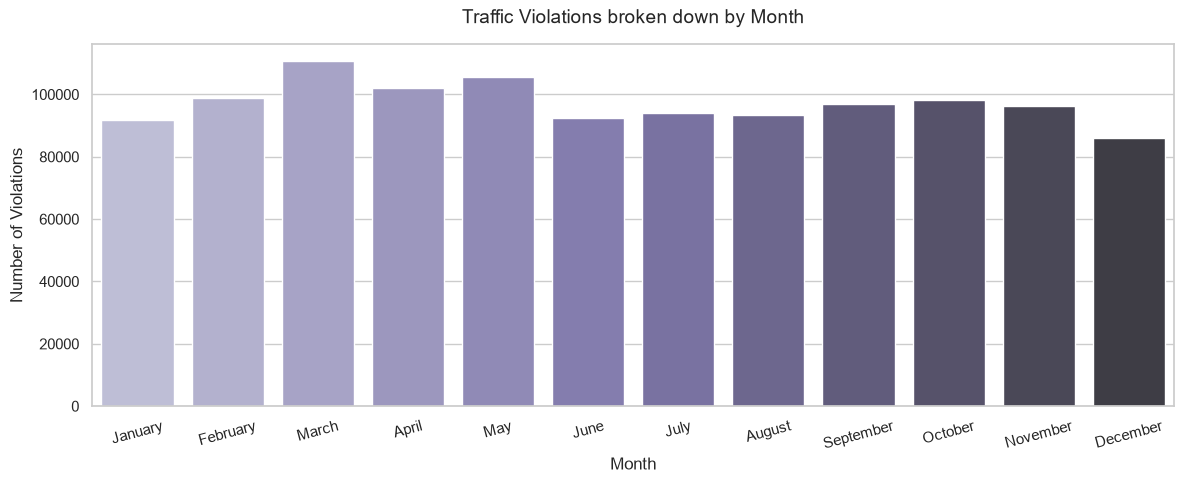

In [21]:
# Q4c: Monthly Distribution
if 'Month' in df.columns:
    plt.figure(figsize=(12, 5))
    
    # Enforce calendar month order
    month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                   'July', 'August', 'September', 'October', 'November', 'December']
    
    # Match against months actually present in your specific slice of data
    existing_months = [m for m in month_order if m in df['Month'].unique()]
    
    sns.countplot(data=df, x='Month', order=existing_months, palette="Purples_d")
    
    plt.title("Traffic Violations broken down by Month", fontsize=14, pad=15)
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Number of Violations", fontsize=12)
    plt.xticks(rotation=15)  # Slight tilt to prevent label overlapping
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Month' not found.")

# Q6 — How often do violations involve accidents, injuries, or vehicle damage?

Accident Rate across all records: 1.919%
Personal Injury Rate across all records: 0.832%
Property Damage Rate across all records: 1.291%
Fatal Rate across all records: 0.026%


C:\Users\Krishnika Arun\AppData\Local\Temp\ipykernel_2596\3325330036.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=available_metrics, y=rates, palette="autumn")


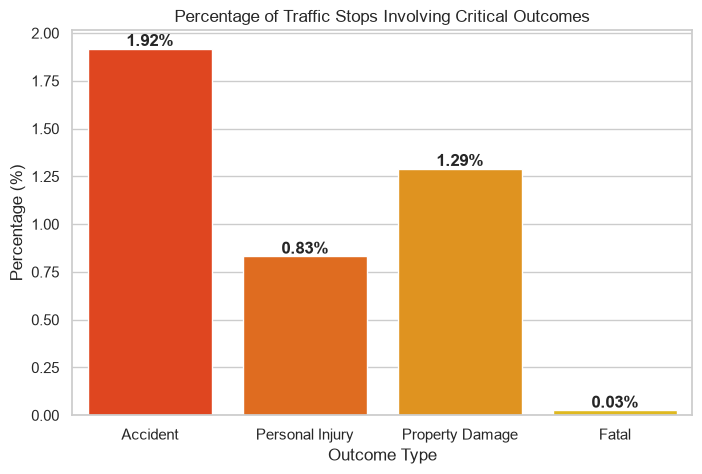

In [14]:
# Cell 8: Q6 — How often do violations involve accidents, injuries, or vehicle damage?

severity_metrics = ['Accident', 'Personal Injury', 'Property Damage', 'Fatal']
rates = []
available_metrics = []

for metric in severity_metrics:
    if metric in df.columns:
        # Since columns are converted to standard True/False, .mean() gives the rate
        rate = df[metric].mean() * 100
        rates.append(rate)
        available_metrics.append(metric)
        print(f"{metric} Rate across all records: {rate:.3f}%")

# Plotting the rates summary
if available_metrics:
    plt.figure(figsize=(8, 5))
    # FIXED: Changed the second argument from x=rates to y=rates
    ax = sns.barplot(x=available_metrics, y=rates, palette="autumn")
    plt.title("Percentage of Traffic Stops Involving Critical Outcomes")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Outcome Type")
    
    # Add values on top of the bars
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
    plt.show()